# ClusterFinder — CPU vs CUDA performance

Throughput comparison of the serial CPU finder against the CUDA variants:
per-frame, batched+pinned, CUDA-Graph, and the async double-buffered pipeline.

CPU↔CUDA **correctness** (why the cluster counts differ) is analysed
separately in `ClusterFinderFrozen_vs_CUDA.ipynb`; here we only sanity-check that
the counts and spectra agree, and focus on timing.

In [1]:
import sys; sys.path.append('/home/ferjao_k/aare/build')

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import boost_histogram as bh
import time
from tqdm import tqdm

from aare import (File, ClusterFinder, ClusterFinderFrozen, ClusterFinderMT, ClusterCollector,
                  ClusterFinderCUDA, ClusterFinderCUDAGraph)
from helper import print_pinning_budget

In [2]:
N_BINS = 200

def make_hist(clusters):
    h = bh.Histogram(bh.axis.Regular(N_BINS, -2, 4000))
    h.fill(clusters.sum())
    return h

def make_hist_from_batch(result_list):
    h = bh.Histogram(bh.axis.Regular(N_BINS, -2, 4000))
    energies = [np.asarray(cv.sum()).ravel() for cv in result_list if cv.size > 0]
    if energies:
        h.fill(np.concatenate(energies))
    return h

In [3]:
base = Path('/mnt/sls_det_storage/moench_data/2603_MaxIVBeamtime/2026032408/process/xrf/')
f = File(base / 'Cu_factor_10_data_master_0.json')
pd = File(base / 'Cu_factor_10_pedestal_master_0.json')

n_frames_pd  = 1000
N            = 20000
cluster_size = (9, 9)
rows, cols   = f.rows, f.cols
image_size   = (rows, cols)
capacity     = 1000
BATCH_SIZE   = 2000

N_STREAMS = 4
N_SIGMA   = 5

print(f'Image size:      {image_size}')
print(f'Pedestal frames: {n_frames_pd}')
print(f'Data frames:     {N}')
print(f'Total in file:   {f.total_frames}')

Image size:      (400, 400)
Pedestal frames: 1000
Data frames:     20000
Total in file:   100000


In [4]:
print_pinning_budget(rows, cols)

── System RAM ──────────────────────────────────────────
  Total RAM           : 125.1 GiB
  Currently available : 112.7 GiB  (free + reclaimable cache)
  Reserved headroom   : 4.0 GiB  (OS + CUDA context)
  Safe pinning budget : 108.7 GiB

── Frame layout ────────────────────────────────────────
  Frame size          : 400 × 400 × 2 B = 312.5 kB

── Pinning estimate ────────────────────────────────────
  Max frames pinnable : 364,859  (108.7 GiB)

  Note: no swap on this machine — exceeding available RAM
  will trigger the OOM killer. Stay within the budget.


## Build finders

`SERIAL` picks the CPU baseline: the sequential `ClusterFinder` or the
multi-threaded `ClusterFinderMT`. All finders are trained on the same pedestal
frames below.

In [5]:
SERIAL = False

if SERIAL:
    # cf_cpu = ClusterFinder(image_size, cluster_size, n_sigma=N_SIGMA, capacity=capacity)
    cf_cpu = ClusterFinderFrozen(image_size, cluster_size, n_sigma=N_SIGMA, capacity=capacity)
else:
    cf_cpu = ClusterFinderMT(image_size, cluster_size, n_sigma=N_SIGMA,
                             capacity=capacity, n_threads=48)
    sink = ClusterCollector(cf_cpu)

cf_cuda_v1 = ClusterFinderCUDA(image_size, cluster_size, n_sigma=N_SIGMA,
                               max_clusters_per_frame=1500, n_streams=N_STREAMS)
cf_cuda    = ClusterFinderCUDA(image_size, cluster_size, n_sigma=N_SIGMA,
                               max_clusters_per_frame=1500, n_streams=N_STREAMS)
# cf_async   = ClusterFinderCUDA(image_size, cluster_size, n_sigma=N_SIGMA,
#                                max_clusters_per_frame=2000, n_streams=N_STREAMS)
cf_graph   = ClusterFinderCUDAGraph(image_size, cluster_size, n_sigma=N_SIGMA,
                                    max_clusters_per_frame=1500, n_streams=N_STREAMS)

## Pedestal (all finders trained on identical frames)

In [6]:
t0 = time.perf_counter()
for _ in range(n_frames_pd):
    img = pd.read_frame()
    cf_cpu.push_pedestal_frame(img.copy())
    cf_cuda_v1.push_pedestal_frame(img.copy())
    cf_cuda.push_pedestal_frame(img.copy())
    # cf_async.push_pedestal_frame(img.copy())
    cf_graph.push_pedestal_frame(img.copy())
print(f'Pedestal ({n_frames_pd} frames): {time.perf_counter() - t0:.3f}s')

Pedestal (1000 frames): 10.831s


## Read all data frames into memory (I/O out of the timing loop)

In [7]:
f.seek(0)
t0 = time.perf_counter()
data = f.read_n(N)
t_io = time.perf_counter() - t0
print(f'Reading {N} frames: {t_io:.3f}s  ({N/t_io:.0f} FPS, '
      f'{f.bytes_per_frame * N / 1024**2 / t_io:.3f} GB/s)')

Reading 20000 frames: 1.074s  (18614 FPS, 5680.686 GB/s)


## CPU clustering (baseline)

In [8]:
t0 = time.perf_counter()
for frame in tqdm(data):
    cf_cpu.find_clusters(frame)
t_cpu = time.perf_counter() - t0

if SERIAL:
    clusters_cpu = cf_cpu.steal_clusters(realloc_same_capacity=False)
    n_clusters_cpu = clusters_cpu.size
    hist_cpu = make_hist(clusters_cpu)
else:
    cf_cpu.stop(); sink.stop()
    clusters_cpu = sink.steal_clusters()
    hist_cpu = bh.Histogram(bh.axis.Regular(N_BINS, -2, 4000))
    n_clusters_cpu = 0
    for cv in clusters_cpu:
        hist_cpu.fill(cv.sum())
        n_clusters_cpu += cv.size

print(f'CPU clustering:       {t_cpu:.3f}s ({N/t_cpu:.0f} FPS, '
      f'{n_clusters_cpu} clusters, {n_clusters_cpu/N:.2f}/frame)')

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 20000/20000 [00:09<00:00, 2184.48it/s]


CPU clustering:       9.158s (2184 FPS, 28438072 clusters, 1421.90/frame)


## CUDA — per-frame (1 launch/frame, pageable memory)
Simplest path: no batching, no pinning. Isolates per-frame launch + PCIe overhead.

In [9]:
cf_cuda_v1.reset_timers()
t0 = time.perf_counter()

n_clusters_cuda_v1 = 0
hist_cuda_v1 = None
for frame in data:
    cf_cuda_v1.find_clusters(frame)
    clusters_frame = cf_cuda_v1.steal_clusters(realloc_same_capacity=True)
    n_clusters_cuda_v1 += clusters_frame.size
    h = make_hist(clusters_frame)
    hist_cuda_v1 = h if hist_cuda_v1 is None else hist_cuda_v1 + h

t_cuda_v1 = time.perf_counter() - t0
kernel_ms = cf_cuda_v1.avg_kernel_time_ms()
print(f'CUDA per-frame:       {t_cuda_v1:.3f}s  ({N/t_cuda_v1:.0f} FPS, '
      f'{n_clusters_cuda_v1} clusters, {n_clusters_cuda_v1/N:.2f}/frame)')
print(f'  Kernel only:        {kernel_ms:.3f} ms/frame')
print(f'  PCIe + overhead:    {t_cuda_v1*1000/N - kernel_ms:.3f} ms/frame')
print(f'Speedup (CPU/CUDA):   {t_cpu / t_cuda_v1:.2f}x')

CUDA per-frame:       3.659s  (5467 FPS, 28445699 clusters, 1422.28/frame)
  Kernel only:        0.034 ms/frame
  PCIe + overhead:    0.149 ms/frame
Speedup (CPU/CUDA):   2.50x


## CUDA — batched + multi-streamed + pinned dataset
Pins the whole input once, then submits `BATCH_SIZE`-frame chunks across `N_STREAMS` streams so H2D / kernel / D2H overlap.

In [10]:
cf_cuda.register_input_buffer(data)   # pin the whole dataset once
clusters_cuda_per_frame = []

cf_cuda.reset_timers()
t0 = time.perf_counter()
for start in range(0, N, BATCH_SIZE):
    stop = min(start + BATCH_SIZE, N)
    clusters_cuda_per_frame.extend(
        cf_cuda.find_clusters_batched(data[start:stop], first_frame=start))
t_cuda = time.perf_counter() - t0

cf_cuda.unregister_input_buffer()
kernel_ms = cf_cuda.avg_kernel_time_ms()
n_clusters_cuda = sum(cv.size for cv in clusters_cuda_per_frame)
hist_cuda = make_hist_from_batch(clusters_cuda_per_frame)

print(f'CUDA batched:         {t_cuda:.3f}s  ({N/t_cuda:.0f} FPS, '
      f'{n_clusters_cuda} clusters, {n_clusters_cuda/N:.2f}/frame)')
print(f'  Kernel only:        {kernel_ms:.3f} ms/frame')
print(f'  PCIe + overhead:    {t_cuda*1000/N - kernel_ms:.3f} ms/frame')
print(f'Speedup (CPU/CUDA):   {t_cpu / t_cuda:.2f}x')

CUDA batched:         3.088s  (6477 FPS, 28439289 clusters, 1421.96/frame)
  Kernel only:        0.031 ms/frame
  PCIe + overhead:    0.123 ms/frame
Speedup (CPU/CUDA):   2.97x


## CUDA — Graph (pinned dataset)
Pre-records the H2D->kernel->D2H pipeline as a CUDA Graph per stream, cutting per-frame CPU API overhead (~21 us vs ~60 us for the streamed version).

In [11]:
cf_graph.register_input_buffer(data)
clusters_graph_per_frame = []

t0 = time.perf_counter()
for start in range(0, N, BATCH_SIZE):
    stop = min(start + BATCH_SIZE, N)
    clusters_graph_per_frame.extend(
        cf_graph.find_clusters_batched(data[start:stop], first_frame=start))
t_graph = time.perf_counter() - t0

cf_graph.unregister_input_buffer()
n_clusters_graph = sum(cv.size for cv in clusters_graph_per_frame)
hist_graph = make_hist_from_batch(clusters_graph_per_frame)

print(f'CUDA Graph:           {t_graph:.3f}s  ({N/t_graph:.0f} FPS, '
      f'{n_clusters_graph} clusters, {n_clusters_graph/N:.2f}/frame)')
print(f'  Kernel+PCIe+ovhd:   {t_graph*1000/N:.3f} ms/frame  (kernel not individually timed)')
print(f'Speedup (vs batched): {t_cuda / t_graph:.2f}x')
print(f'Speedup (CPU/Graph):  {t_cpu / t_graph:.2f}x')

CUDA Graph:           3.132s  (6386 FPS, 28439289 clusters, 1421.96/frame)
  Kernel+PCIe+ovhd:   0.157 ms/frame  (kernel not individually timed)
Speedup (vs batched): 0.99x
Speedup (CPU/Graph):  2.92x


## CUDA — async double-buffered pipeline
Two pinned batch buffers: while the GPU processes `buf[cur]`, the CPU fills `buf[nxt]`, so H2D copies and kernels stay back-to-back.

In [12]:
# buf = [np.empty((BATCH_SIZE, rows, cols), dtype=np.uint16) for _ in range(2)]
# cf_async.pin_buffer(buf[0])
# cf_async.pin_buffer(buf[1])

# clusters_async = []
# cf_async.reset_timers()
# t0 = time.perf_counter()

# cur = 0
# n0 = min(BATCH_SIZE, N)
# buf[cur][:n0] = data[:n0]
# tok = cf_async.submit_batch(buf[cur][:n0], first_frame=0)

# for start in range(BATCH_SIZE, N, BATCH_SIZE):
#     nxt  = 1 - cur
#     stop = min(start + BATCH_SIZE, N)
#     n    = stop - start
#     buf[nxt][:n] = data[start:stop]              # fill next while GPU runs current
#     next_tok = cf_async.submit_batch(buf[nxt][:n], first_frame=start)
#     clusters_async.extend(cf_async.collect(tok))  # drain previous
#     tok = next_tok
#     cur = nxt
# clusters_async.extend(cf_async.collect(tok))      # drain final

# t_async = time.perf_counter() - t0
# cf_async.unpin_buffer(buf[0]); cf_async.unpin_buffer(buf[1])

# kernel_ms_async = cf_async.avg_kernel_time_ms()
# n_clusters_async = sum(cv.size for cv in clusters_async)
# hist_async = make_hist_from_batch(clusters_async)

# print(f'CUDA async pipeline:  {t_async:.3f}s  ({N/t_async:.0f} FPS, '
#       f'{n_clusters_async} clusters, {n_clusters_async/N:.2f}/frame)')
# print(f'  Kernel only:        {kernel_ms_async:.3f} ms/frame')
# print(f'  PCIe + overhead:    {t_async*1000/N - kernel_ms_async:.3f} ms/frame')
# print(f'Speedup (vs Graph):   {t_graph / t_async:.2f}x')

## Agreement sanity check
Counts should match to a hair. The residual comes from the CUDA finder updating the pedestal once per frame vs the CPU's per-pixel update (analysed in `ClusterFinderFrozen_vs_CUDA.ipynb`).

In [13]:
for name, n in [('CPU', n_clusters_cpu), ('CUDA per-frame', n_clusters_cuda_v1),
                ('CUDA batched', n_clusters_cuda), ('CUDA graph', n_clusters_graph)]:
                # ('CUDA async', n_clusters_async)]:
    d = abs(n - n_clusters_cpu)
    print(f'  {name:<16} {n:>12,}   diff vs CPU {d:>6,}  ({d/max(n_clusters_cpu,1):.4%})')

  CPU                28,438,072   diff vs CPU      0  (0.0000%)
  CUDA per-frame     28,445,699   diff vs CPU  7,627  (0.0268%)
  CUDA batched       28,439,289   diff vs CPU  1,217  (0.0043%)
  CUDA graph         28,439,289   diff vs CPU  1,217  (0.0043%)


## Spectrum: CPU vs CUDA variants

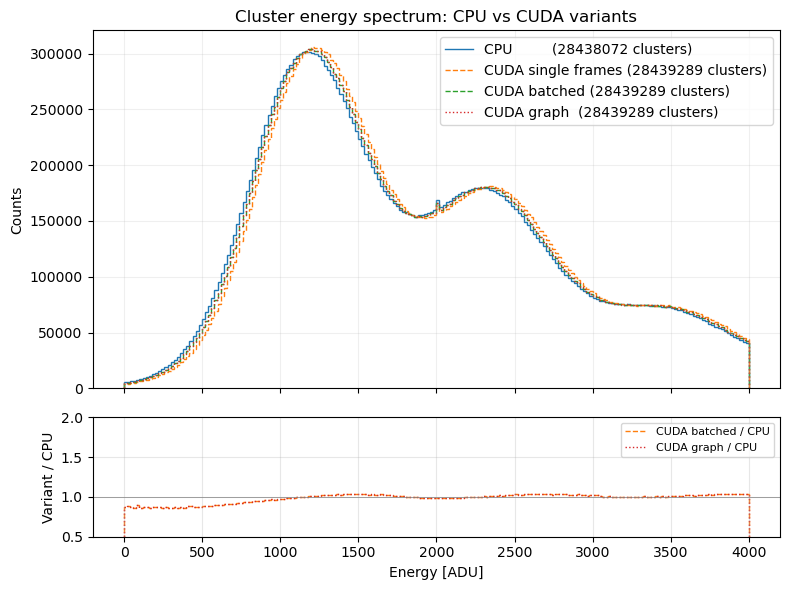

In [14]:
fig, (ax_spec, ax_ratio) = plt.subplots(
    2, 1, figsize=(8, 6), sharex=True,
    gridspec_kw={'height_ratios': [3, 1]})

edges = hist_cpu.axes[0].edges
cpu_vals   = hist_cpu.values()
cuda_vals_v1  = hist_cuda_v1.values()
cuda_vals  = hist_cuda.values()
# async_vals = hist_async.values()
graph_vals = hist_graph.values()

ax_spec.stairs(cpu_vals,   edges, label=f'CPU         ({n_clusters_cpu} clusters)')
ax_spec.stairs(cuda_vals_v1,  edges, label=f'CUDA single frames ({n_clusters_cuda} clusters)', linestyle='--')
ax_spec.stairs(cuda_vals,  edges, label=f'CUDA batched ({n_clusters_cuda} clusters)', linestyle='--')
# ax_spec.stairs(async_vals, edges, label=f'CUDA async  ({n_clusters_async} clusters)', linestyle='-.')
ax_spec.stairs(graph_vals, edges, label=f'CUDA graph  ({n_clusters_graph} clusters)', linestyle=':')
ax_spec.set_ylabel('Counts')
ax_spec.set_title('Cluster energy spectrum: CPU vs CUDA variants')
ax_spec.legend()
ax_spec.grid(alpha=0.2)

with np.errstate(divide='ignore', invalid='ignore'):
    ratio_cuda  = np.where(cpu_vals > 0, cuda_vals  / cpu_vals, np.nan)
    ratio_graph = np.where(cpu_vals > 0, graph_vals / cpu_vals, np.nan)

ax_ratio.stairs(ratio_cuda,  edges, label='CUDA batched / CPU', color='C1', linestyle='--')
ax_ratio.stairs(ratio_graph, edges, label='CUDA graph / CPU',  color='C3', linestyle=':')
ax_ratio.axhline(1.0, color='gray', linewidth=0.5)
ax_ratio.set_ylabel('Variant / CPU')
ax_ratio.set_xlabel('Energy [ADU]')
ax_ratio.set_ylim(0.5, 2.0)
ax_ratio.legend(fontsize=8)
ax_ratio.grid(alpha=0.3)

plt.tight_layout()
plt.show()